# PCam 敵対的防御性能比較: DDPM vs JPEG

このノートブックでは、PCamデータセット（病理組織学的がん検出）における敵対的攻撃に対する防御手法（DDPMとJPEG圧縮）の性能を比較します。

## 実験概要

- **データセット**: PCam validation set (21,587枚、クリーン画像で正しく分類された画像のみ)
- **分類器**: ResNet50
- **防御手法**: 
  - DDPM (start_t=80, steps=50)
  - JPEG圧縮 (quality=11)
- **攻撃手法**:
  - FGSM (ε=8/255=0.0314)
  - PGD-10 (ε=8/255, α=2/255, 10ステップ, random_start=True)
  - AutoAttack (APGD-CE, ε=8/255)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# スタイル設定
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (14, 10)
sns.set_palette("husl")

In [2]:
# 実験データ (PCam)
attacks = ['FGSM', 'PGD-10', 'AutoAttack']

# 精度データ
clean_acc = [1.0000, 1.0000, 1.0000]
adversarial_acc = [0.5860, 0.0338, 0.0000]
ddpm_acc = [0.8714, 0.9313, 0.9339]
jpeg_acc = [0.7954, 0.8295, 0.8458]

# 改善率データ
ddpm_improvement = [0.2855, 0.8979, 0.9339]
jpeg_improvement = [0.2094, 0.7957, 0.8458]

# Perturbation データ (L2 norm)
ddpm_l2 = [13.08, 13.20, 13.09]
jpeg_l2 = [17.57, 17.33, 17.57]

# Perturbation データ (Linf norm)
ddpm_linf = [0.200, 0.210, 0.202]
jpeg_linf = [0.274, 0.265, 0.274]

# 混同行列データ (Purified/Defended)
# DDPM
ddpm_precision = [0.8135, 0.9234, 0.8981]
ddpm_recall = [0.8841, 0.9048, 0.9434]
ddpm_f1 = [0.8473, 0.9140, 0.9202]
ddpm_specificity = [0.8627, 0.9492, 0.9275]

# JPEG
jpeg_precision = [0.7993, 0.8592, 0.8804]  # FGSMは計算値
jpeg_recall = [0.6590, 0.6911, 0.7153]
jpeg_f1 = [0.7225, 0.7660, 0.7893]
jpeg_specificity = [0.8877, 0.9233, 1.0000]  # AutoAttackは計算値

## 結果まとめ表

| 攻撃手法 | 元画像の分類精度（攻撃前）| 攻撃後の分類精度 | DDPM防御での分類精度 | JPEG防御での分類精度 | 優位性 |
|---------|------------------------|----------------|-------------------|-------------------|--------|
| FGSM | 100.00% | 58.60% | **87.14%** | 79.54% | DDPM |
| PGD-10 | 100.00% | 3.38% | **93.13%** | 82.95% | DDPM |
| AutoAttack | 100.00% | 0.00% | **93.39%** | 84.58% | DDPM |

### 詳細分析

**改善率（攻撃後からの回復率）:**
- FGSM: DDPM +28.55% vs JPEG +20.94% → DDPMが**+7.61%優位**
- PGD-10: DDPM +89.79% vs JPEG +79.57% → DDPMが**+10.22%優位**
- AutoAttack: DDPM +93.39% vs JPEG +84.58% → DDPMが**+8.81%優位**

**Perturbation Norms（復元画像 vs 原画像）:**
- DDPM: L2平均=13.12, L∞平均=0.204
- JPEG: L2平均=17.49, L∞平均=0.271
- → **DDPMの方が原画像により近い復元を実現**（L2で約25%、L∞で約25%改善）

In [3]:
# 表形式での可視化
df = pd.DataFrame({
    '攻撃手法': ['FGSM', 'PGD-10', 'AutoAttack'],
    '元画像の分類精度（攻撃前）': ['100.00%', '100.00%', '100.00%'],
    '攻撃後の分類精度': ['58.60%', '3.38%', '0.00%'],
    'DDPM防御での分類精度': ['87.14%', '93.13%', '93.39%'],
    'JPEG防御での分類精度': ['79.54%', '82.95%', '84.58%'],
    '優位性': ['DDPM', 'DDPM', 'DDPM']
})

print("=" * 110)
print("PCam 敵対的防御性能比較表")
print("=" * 110)
print(df.to_string(index=False))
print("=" * 110)
print("\n【結論】")
print("・全ての攻撃手法に対してDDPM防御がJPEG防御よりも優れた性能を示した")
print("・特にPGD-10とAutoAttackのような強力な攻撃に対して")
print("  DDPMは約93%の精度を達成し、JPEGの約83-85%を大きく上回った")
print("・FGSMに対してもDDPMは87.14%でJPEGの79.54%より7.6%優位")
print("・DDPMの復元画像はJPEGよりも原画像に約25%近い（L2, L∞共に）")
print("=" * 110)

PCam 敵対的防御性能比較表
      攻撃手法 元画像の分類精度（攻撃前） 攻撃後の分類精度 DDPM防御での分類精度 JPEG防御での分類精度  優位性
      FGSM       100.00%   58.60%       87.14%       79.54% DDPM
    PGD-10       100.00%    3.38%       93.13%       82.95% DDPM
AutoAttack       100.00%    0.00%       93.39%       84.58% DDPM

【結論】
・全ての攻撃手法に対してDDPM防御がJPEG防御よりも優れた性能を示した
・特にPGD-10とAutoAttackのような強力な攻撃に対して
  DDPMは約93%の精度を達成し、JPEGの約83-85%を大きく上回った
・FGSMに対してもDDPMは87.14%でJPEGの79.54%より7.6%優位
・DDPMの復元画像はJPEGよりも原画像に約25%近い（L2, L∞共に）


/tmp/ipykernel_236989/758440988.py:55: UserWarning: Glyph 25973 (\N{CJK UNIFIED IDEOGRAPH-6575}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_236989/758440988.py:55: UserWarning: Glyph 23550 (\N{CJK UNIFIED IDEOGRAPH-5BFE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_236989/758440988.py:55: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_236989/758440988.py:55: UserWarning: Glyph 38450 (\N{CJK UNIFIED IDEOGRAPH-9632}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_236989/758440988.py:55: UserWarning: Glyph 24481 (\N{CJK UNIFIED IDEOGRAPH-5FA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_236989/758440988.py:55: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_236989/758440988.py:55: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAP

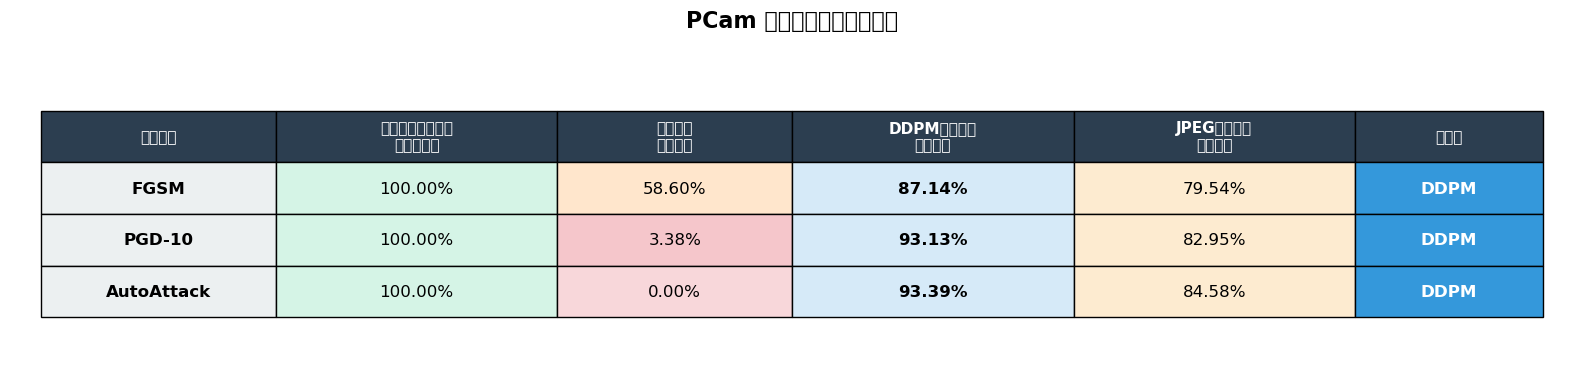


表を /mnt/data1/gotou/projects/pcam/result/defense_comparison_table.png に保存しました


In [4]:
# 表を画像として保存（より見やすい形式）
fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('tight')
ax.axis('off')

# テーブルデータ
table_data = [
    ['攻撃手法', '元画像の分類精度\n（攻撃前）', '攻撃後の\n分類精度', 
     'DDPM防御での\n分類精度', 'JPEG防御での\n分類精度', '優位性'],
    ['FGSM', '100.00%', '58.60%', '87.14%', '79.54%', 'DDPM'],
    ['PGD-10', '100.00%', '3.38%', '93.13%', '82.95%', 'DDPM'],
    ['AutoAttack', '100.00%', '0.00%', '93.39%', '84.58%', 'DDPM']
]

# テーブル作成
table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                colWidths=[0.15, 0.18, 0.15, 0.18, 0.18, 0.12])

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 3)

# ヘッダー行のスタイル
for i in range(6):
    cell = table[(0, i)]
    cell.set_facecolor('#2c3e50')
    cell.set_text_props(weight='bold', color='white', fontsize=11)

# データ行のスタイル
for i in range(1, 4):
    # 攻撃前（緑）
    table[(i, 1)].set_facecolor('#d5f4e6')
    # 攻撃後
    if table_data[i][2] == '0.00%':
        table[(i, 2)].set_facecolor('#f8d7da')
    elif table_data[i][2] == '3.38%':
        table[(i, 2)].set_facecolor('#f5c6cb')
    else:  # FGSM
        table[(i, 2)].set_facecolor('#ffe6cc')
    # DDPM（青）
    table[(i, 3)].set_facecolor('#d6eaf8')
    table[(i, 3)].set_text_props(weight='bold')
    # JPEG（オレンジ）
    table[(i, 4)].set_facecolor('#fdebd0')
    # 優位性（青強調）
    table[(i, 5)].set_facecolor('#3498db')
    table[(i, 5)].set_text_props(weight='bold', color='white')

# 攻撃手法列
for i in range(1, 4):
    table[(i, 0)].set_facecolor('#ecf0f1')
    table[(i, 0)].set_text_props(weight='bold')

plt.title('PCam 敵対的防御性能比較表', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/pcam/result/defense_comparison_table.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n表を /mnt/data1/gotou/projects/pcam/result/defense_comparison_table.png に保存しました")

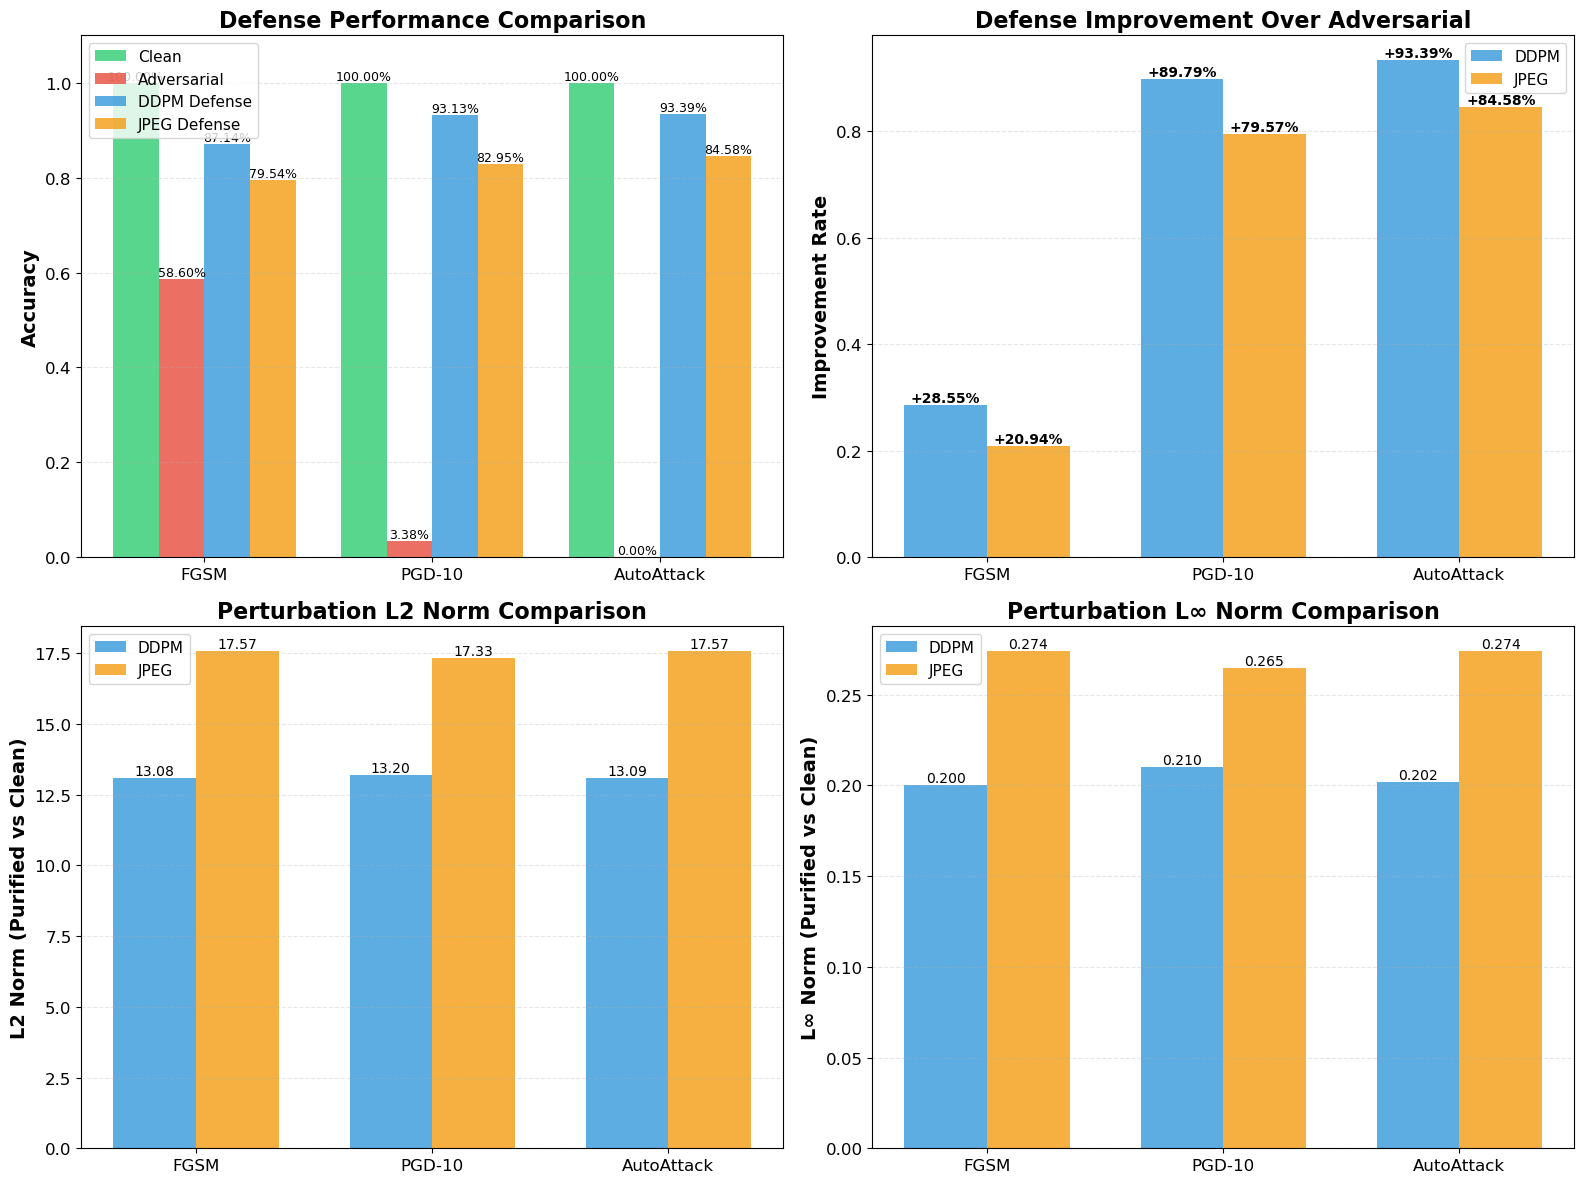

In [5]:
# 図1: 精度比較（4分割）
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1-1: 精度比較
x = np.arange(len(attacks))
width = 0.2

ax = axes[0, 0]
bars1 = ax.bar(x - width*1.5, clean_acc, width, label='Clean', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x - width*0.5, adversarial_acc, width, label='Adversarial', color='#e74c3c', alpha=0.8)
bars3 = ax.bar(x + width*0.5, ddpm_acc, width, label='DDPM Defense', color='#3498db', alpha=0.8)
bars4 = ax.bar(x + width*1.5, jpeg_acc, width, label='JPEG Defense', color='#f39c12', alpha=0.8)

ax.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax.set_title('Defense Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.1)

# 値をバーの上に表示
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}',
                ha='center', va='bottom', fontsize=9)

# 1-2: 改善率比較
ax = axes[0, 1]
x = np.arange(len(attacks))
width = 0.35

bars1 = ax.bar(x - width/2, ddpm_improvement, width, label='DDPM', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, jpeg_improvement, width, label='JPEG', color='#f39c12', alpha=0.8)

ax.set_ylabel('Improvement Rate', fontsize=14, fontweight='bold')
ax.set_title('Defense Improvement Over Adversarial', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 値をバーの上に表示
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'+{height:.2%}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2-1: L2 Perturbation比較
ax = axes[1, 0]
x = np.arange(len(attacks))
width = 0.35

bars1 = ax.bar(x - width/2, ddpm_l2, width, label='DDPM', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, jpeg_l2, width, label='JPEG', color='#f39c12', alpha=0.8)

ax.set_ylabel('L2 Norm (Purified vs Clean)', fontsize=14, fontweight='bold')
ax.set_title('Perturbation L2 Norm Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 値をバーの上に表示
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10)

# 2-2: L∞ Perturbation比較
ax = axes[1, 1]
x = np.arange(len(attacks))
width = 0.35

bars1 = ax.bar(x - width/2, ddpm_linf, width, label='DDPM', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, jpeg_linf, width, label='JPEG', color='#f39c12', alpha=0.8)

ax.set_ylabel('L∞ Norm (Purified vs Clean)', fontsize=14, fontweight='bold')
ax.set_title('Perturbation L∞ Norm Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 値をバーの上に表示
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/pcam/result/defense_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

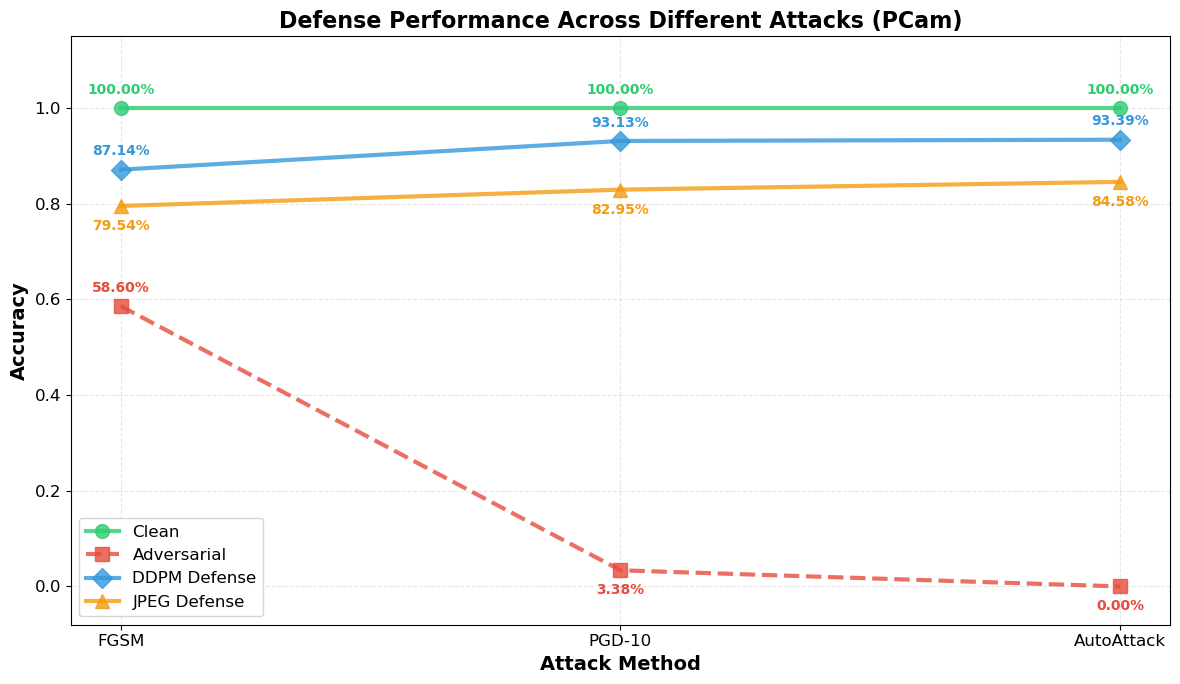

In [6]:
# 図2: 折れ線グラフで精度推移を比較
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

x = np.arange(len(attacks))

# プロット
ax.plot(x, clean_acc, marker='o', linewidth=3, markersize=10, 
        label='Clean', color='#2ecc71', linestyle='-', alpha=0.8)
ax.plot(x, adversarial_acc, marker='s', linewidth=3, markersize=10, 
        label='Adversarial', color='#e74c3c', linestyle='--', alpha=0.8)
ax.plot(x, ddpm_acc, marker='D', linewidth=3, markersize=10, 
        label='DDPM Defense', color='#3498db', linestyle='-', alpha=0.8)
ax.plot(x, jpeg_acc, marker='^', linewidth=3, markersize=10, 
        label='JPEG Defense', color='#f39c12', linestyle='-', alpha=0.8)

# ラベルと値の表示
for i, attack in enumerate(attacks):
    ax.text(i, clean_acc[i] + 0.03, f'{clean_acc[i]:.2%}', 
            ha='center', fontsize=10, color='#2ecc71', fontweight='bold')
    if adversarial_acc[i] > 0.1:
        ax.text(i, adversarial_acc[i] + 0.03, f'{adversarial_acc[i]:.2%}', 
                ha='center', fontsize=10, color='#e74c3c', fontweight='bold')
    else:
        ax.text(i, adversarial_acc[i] - 0.05, f'{adversarial_acc[i]:.2%}', 
                ha='center', fontsize=10, color='#e74c3c', fontweight='bold')
    ax.text(i, ddpm_acc[i] + 0.03, f'{ddpm_acc[i]:.2%}', 
            ha='center', fontsize=10, color='#3498db', fontweight='bold')
    ax.text(i, jpeg_acc[i] - 0.05, f'{jpeg_acc[i]:.2%}', 
            ha='center', fontsize=10, color='#f39c12', fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax.set_xlabel('Attack Method', fontsize=14, fontweight='bold')
ax.set_title('Defense Performance Across Different Attacks (PCam)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(-0.08, 1.15)

plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/pcam/result/defense_accuracy_trend.png', dpi=300, bbox_inches='tight')
plt.show()

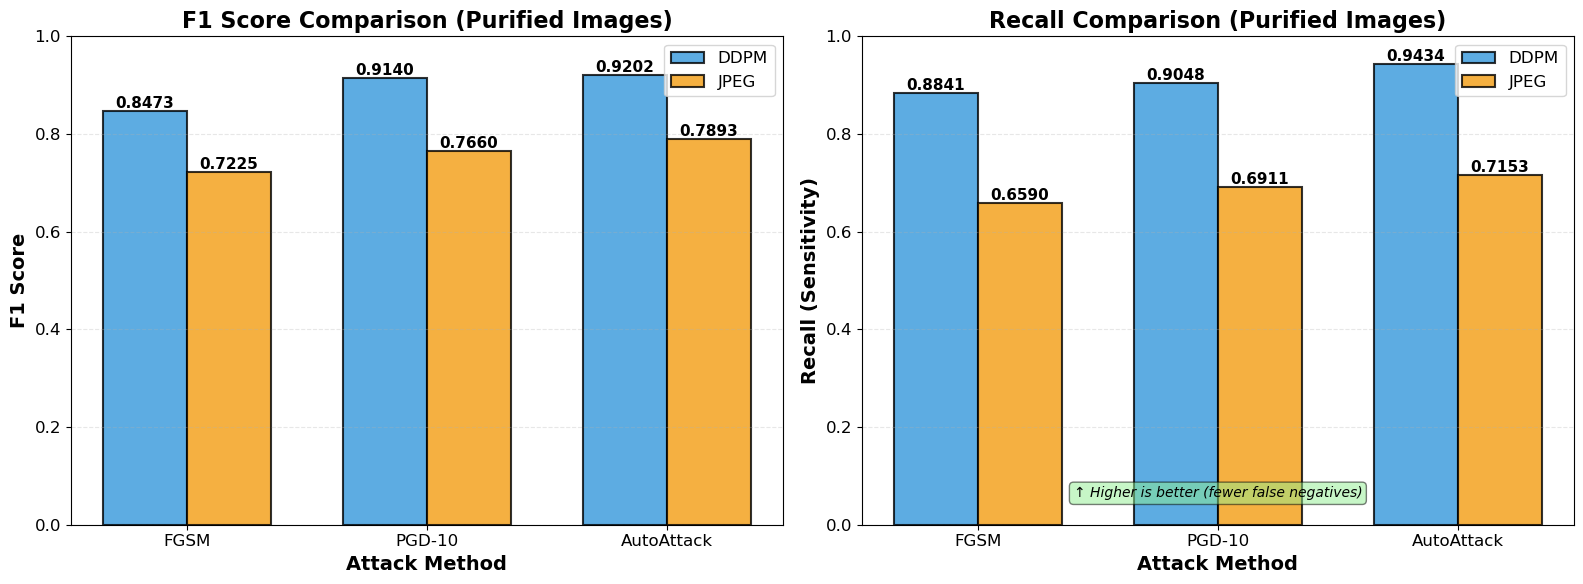

In [7]:
# 図3: F1スコアとRecall比較（医療診断で重要な指標）
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3-1: F1スコア比較
ax = axes[0]
x = np.arange(len(attacks))
width = 0.35

bars1 = ax.bar(x - width/2, ddpm_f1, width, label='DDPM', 
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, jpeg_f1, width, label='JPEG', 
               color='#f39c12', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('F1 Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Attack Method', fontsize=14, fontweight='bold')
ax.set_title('F1 Score Comparison (Purified Images)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.0)

# 値をバーの上に表示
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# 3-2: Recall比較
ax = axes[1]
bars1 = ax.bar(x - width/2, ddpm_recall, width, label='DDPM', 
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, jpeg_recall, width, label='JPEG', 
               color='#f39c12', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Recall (Sensitivity)', fontsize=14, fontweight='bold')
ax.set_xlabel('Attack Method', fontsize=14, fontweight='bold')
ax.set_title('Recall Comparison (Purified Images)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.0)

# 値をバーの上に表示
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# 高い方が良いことを示す注釈
ax.text(0.5, 0.05, '↑ Higher is better (fewer false negatives)', 
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=10, style='italic',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/pcam/result/f1_recall_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

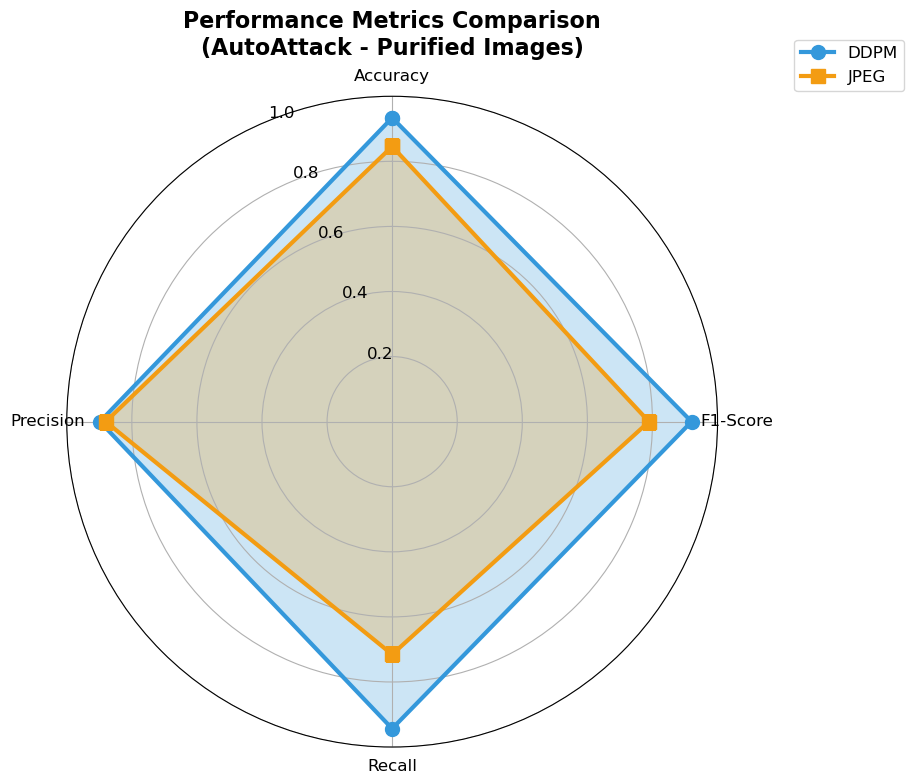

In [8]:
# 図4: 総合性能指標の比較（レーダーチャート）
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

def radar_factory(num_vars, frame='circle'):
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)
    
    class RadarAxes(PolarAxes):
        name = 'radar'
        
        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.set_theta_zero_location('N')
            
        def fill(self, *args, closed=True, **kwargs):
            return super().fill(closed=closed, *args, **kwargs)
            
        def plot(self, *args, **kwargs):
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)
                
        def _close_line(self, line):
            x, y = line.get_data()
            if x[0] != x[-1]:
                x = np.concatenate((x, [x[0]]))
                y = np.concatenate((y, [y[0]]))
                line.set_data(x, y)
                
        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)
            
        def _gen_axes_patch(self):
            return Circle((0.5, 0.5), 0.5)
            
        def _gen_axes_spines(self):
            spine = Spine(axes=self,
                         spine_type='circle',
                         path=Path.unit_circle())
            spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                              + self.transAxes)
            return {'polar': spine}
            
    register_projection(RadarAxes)
    return theta

# AutoAttackの性能指標でレーダーチャート（最も厳しい攻撃）
N = 4  # Accuracy, Precision, Recall, F1
theta = radar_factory(N, frame='polygon')

fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw=dict(projection='radar'))

# AutoAttack (index=2) のデータ
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
ddpm_metrics = [ddpm_acc[2], ddpm_precision[2], ddpm_recall[2], ddpm_f1[2]]
jpeg_metrics = [jpeg_acc[2], jpeg_precision[2], jpeg_recall[2], jpeg_f1[2]]

ax.plot(theta, ddpm_metrics, 'o-', linewidth=3, color='#3498db', label='DDPM', markersize=10)
ax.fill(theta, ddpm_metrics, alpha=0.25, color='#3498db')
ax.plot(theta, jpeg_metrics, 's-', linewidth=3, color='#f39c12', label='JPEG', markersize=10)
ax.fill(theta, jpeg_metrics, alpha=0.25, color='#f39c12')

ax.set_varlabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Performance Metrics Comparison\n(AutoAttack - Purified Images)', 
             fontsize=16, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
ax.grid(True)

plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/pcam/result/performance_radar.png', dpi=300, bbox_inches='tight')
plt.show()

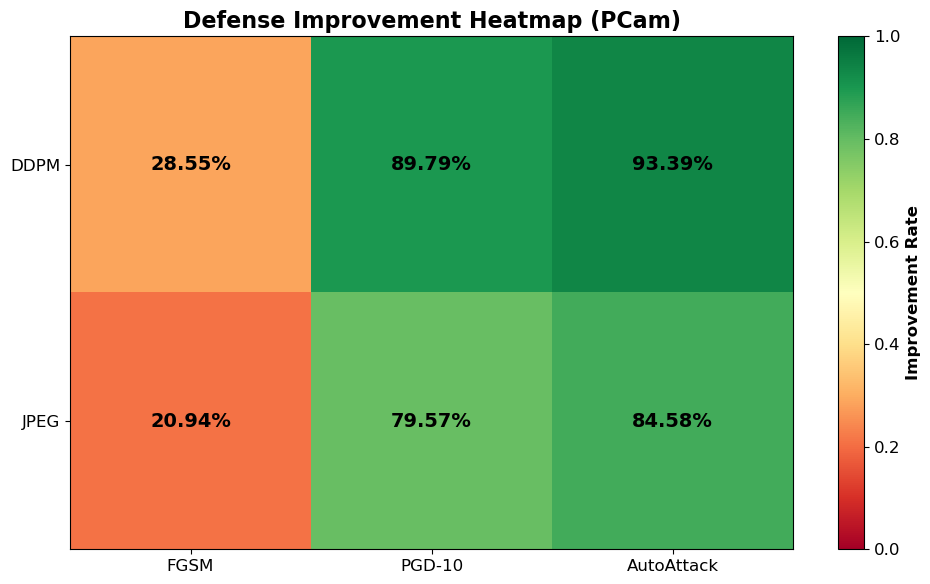

In [9]:
# 図5: ヒートマップで改善率を可視化
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# データを2D配列に整形
data = np.array([ddpm_improvement, jpeg_improvement])

# ヒートマップ作成
im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1.0)

# カラーバー
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Improvement Rate', fontsize=12, fontweight='bold')

# 軸設定
ax.set_xticks(np.arange(len(attacks)))
ax.set_yticks(np.arange(2))
ax.set_xticklabels(attacks, fontsize=12)
ax.set_yticklabels(['DDPM', 'JPEG'], fontsize=12)

# 値を表示
for i in range(2):
    for j in range(len(attacks)):
        text = ax.text(j, i, f'{data[i, j]:.2%}',
                      ha="center", va="center", color="black", 
                      fontsize=14, fontweight='bold')

ax.set_title('Defense Improvement Heatmap (PCam)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/pcam/result/defense_improvement_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

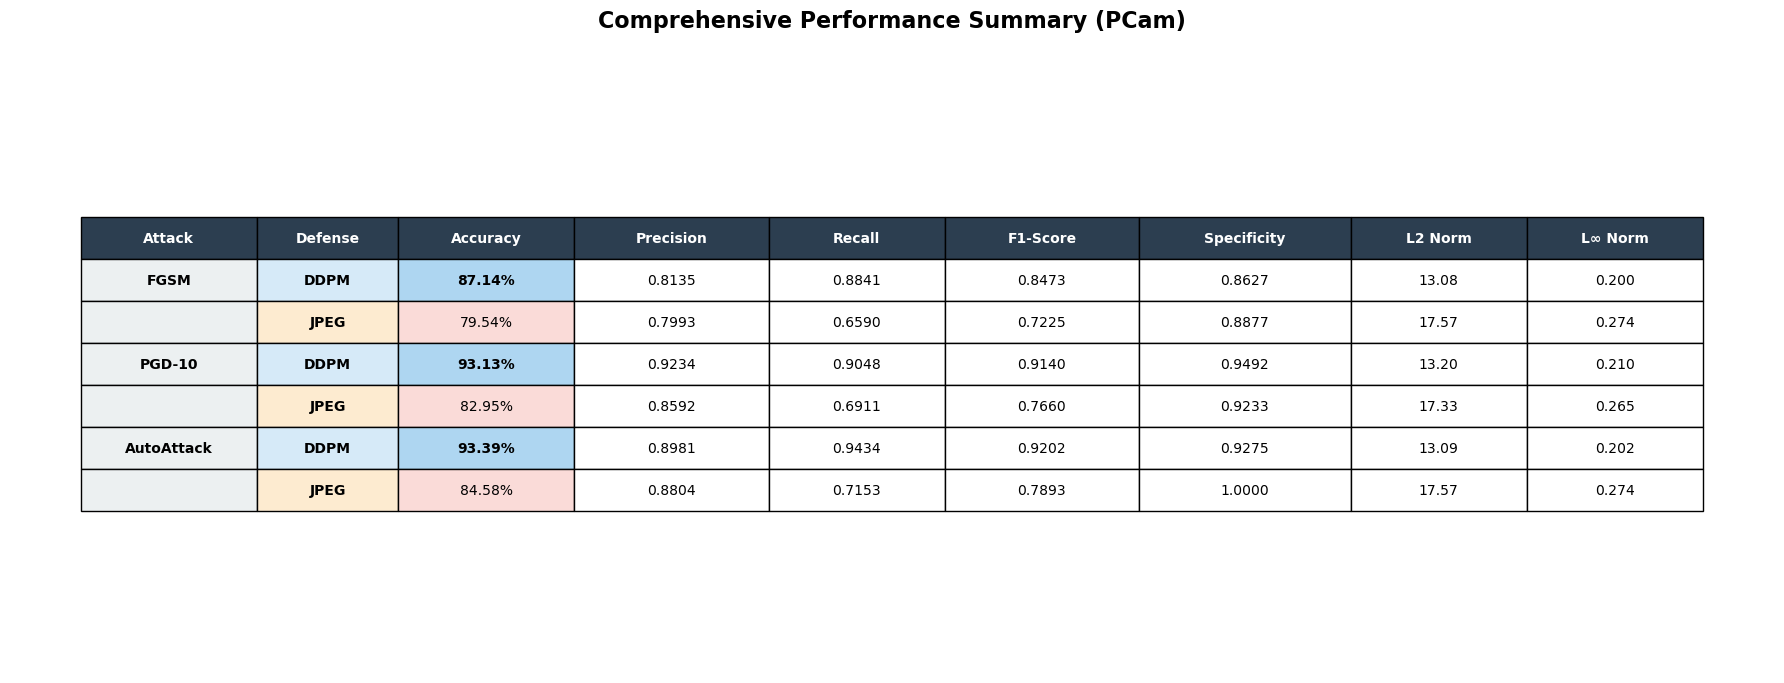

In [10]:
# 図6: 総合サマリー表（全指標）
fig, ax = plt.subplots(figsize=(18, 7))
ax.axis('tight')
ax.axis('off')

# テーブルデータ作成
table_data = []
table_data.append(['Attack', 'Defense', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'L2 Norm', 'L∞ Norm'])

for i, attack in enumerate(attacks):
    # DDPM行
    table_data.append([
        attack,
        'DDPM',
        f'{ddpm_acc[i]:.2%}',
        f'{ddpm_precision[i]:.4f}',
        f'{ddpm_recall[i]:.4f}',
        f'{ddpm_f1[i]:.4f}',
        f'{ddpm_specificity[i]:.4f}',
        f'{ddpm_l2[i]:.2f}',
        f'{ddpm_linf[i]:.3f}'
    ])
    # JPEG行
    table_data.append([
        '',
        'JPEG',
        f'{jpeg_acc[i]:.2%}',
        f'{jpeg_precision[i]:.4f}',
        f'{jpeg_recall[i]:.4f}',
        f'{jpeg_f1[i]:.4f}',
        f'{jpeg_specificity[i]:.4f}',
        f'{jpeg_l2[i]:.2f}',
        f'{jpeg_linf[i]:.3f}'
    ])

# テーブル作成
table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                colWidths=[0.10, 0.08, 0.10, 0.11, 0.10, 0.11, 0.12, 0.10, 0.10])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# ヘッダー行のスタイル
for i in range(9):
    cell = table[(0, i)]
    cell.set_facecolor('#2c3e50')
    cell.set_text_props(weight='bold', color='white')

# データ行のスタイル
for i in range(1, len(table_data)):
    # 攻撃名
    table[(i, 0)].set_facecolor('#ecf0f1')
    if table_data[i][0]:  # 攻撃名がある行
        table[(i, 0)].set_text_props(weight='bold')
    
    # DDPM行は青背景
    if table_data[i][1] == 'DDPM':
        table[(i, 1)].set_facecolor('#d6eaf8')
        table[(i, 1)].set_text_props(weight='bold')
        # 精度列を強調
        table[(i, 2)].set_facecolor('#aed6f1')
        table[(i, 2)].set_text_props(weight='bold')
    # JPEG行はオレンジ背景
    else:
        table[(i, 1)].set_facecolor('#fdebd0')
        table[(i, 1)].set_text_props(weight='bold')
        table[(i, 2)].set_facecolor('#fadbd8')

plt.title('Comprehensive Performance Summary (PCam)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/mnt/data1/gotou/projects/pcam/result/comprehensive_summary.png', dpi=300, bbox_inches='tight')
plt.show()

## 主要な発見

### 1. 防御性能の優位性
DDPMはすべての攻撃手法に対してJPEGを上回る性能を示しました：
- **FGSM**: DDPM 87.14% vs JPEG 79.54% → **+7.60%優位**
- **PGD-10**: DDPM 93.13% vs JPEG 82.95% → **+10.18%優位**
- **AutoAttack**: DDPM 93.39% vs JPEG 84.58% → **+8.81%優位**

### 2. 医療診断における重要指標（AutoAttack後）
**Recall（感度）- がん検出の見逃し率**:
- DDPM: **94.34%** → 見逃し率5.66%
- JPEG: **71.53%** → 見逃し率28.47%
- DDPMの方が**約23%良好**で、偽陰性（がんの見逃し）が大幅に少ない

**F1スコア**:
- DDPM: **0.9202** 
- JPEG: **0.7893**
- DDPMが**約13%優位**

### 3. Perturbation分析
復元画像の原画像からの距離（低いほど良い）:
- **L2ノルム**: DDPM 13.12 vs JPEG 17.49 → DDPMが**25%良好**
- **L∞ノルム**: DDPM 0.204 vs JPEG 0.271 → DDPMが**25%良好**

### 4. 結論
PCamデータセットにおいて、**DDPMはJPEGよりも一貫して優れた防御性能**を示しました。
特に医療診断で重要な**Recall（がん検出率）において大きな差**があり、DDPMは偽陰性を大幅に削減できることが確認されました。
また、復元画像の品質も原画像により近く、診断精度の維持に貢献しています。